In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import d2lzh_pytorch as d2l

In [15]:
class Rnn(nn.Module):
    def __init__(self, input_size, hidden_dim, n_layer, n_classes):
        super(Rnn, self).__init__()
        self.n_layer = n_layer
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_size, hidden_dim, n_layer, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, n_classes)
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        # 此时可以从out中获得最终输出的状态h
        # x = out[:, -1, :]
        x = h_n[-1, :, :]
        x = self.classifier(x)
        return x

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
]) 

# 训练集和 DataLoader
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)  # 修正：DataLoader

# 测试集和 DataLoader
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False)  # 修正：DataLoader

100%|██████████| 26421880/26421880 [09:52<00:00, 44579.12it/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 80957.14it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [01:02<00:00, 70625.78it/s] 


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<?, ?it/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



In [17]:
# 测试 DataLoader
for batch_idx, (inputs, targets) in enumerate(testloader):
    print(inputs.size())
    print(targets)
    break

# 调用 RNN 类
net = Rnn(28, 10, 2, 10)  # 确保 Rnn 类已正确定义
net = net.to('cpu')

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

torch.Size([100, 1, 28, 28])
tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5, 7, 9,
        1, 4, 6, 0, 9, 3, 8, 8, 3, 3, 8, 0, 7, 5, 7, 9, 6, 1, 3, 7, 6, 7, 2, 1,
        2, 2, 4, 4, 5, 8, 2, 2, 8, 4, 8, 0, 7, 7, 8, 5, 1, 1, 2, 3, 9, 8, 7, 0,
        2, 6, 2, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2, 0, 6, 5, 3, 6, 7, 1, 8,
        0, 1, 4, 2])


In [18]:
# Training
def train(epoch):
    print('\nEpoch: %d' % epoch)
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx,(inputs, targets) in enumerate(trainloader):
        inputs,targets = inputs.to('cpu'),targets.to('cpu')
        optimizer.zero_grad()
        outputs = net(torch.squeeze(inputs, 1))
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        print(batch_idx, len(trainloader), 'Loss: %.3f | Acc: %.3f%% (%d/%d)'
              % (train_loss/(batch_idx+1), 100.*correct/total, correct, total))

In [19]:
def test(epoch):
    global best_acc
    net.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(testloader):
            inputs, targets = inputs.to('cpu'), targets.to('cpu')
            outputs = net(torch.squeeze(inputs, 1))
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            print(batch_idx, len(testloader), 'Loss: %.3f | Acc: %.3f%% (%d/%d)'
                  % (test_loss/(batch_idx+1), 100.*correct/total, correct, total))

In [22]:
for epoch in range(5):
    train(epoch)
    test(epoch)


Epoch: 0
0 469 Loss: 0.485 | Acc: 83.594% (107/128)
1 469 Loss: 0.491 | Acc: 84.766% (217/256)
2 469 Loss: 0.459 | Acc: 85.156% (327/384)
3 469 Loss: 0.468 | Acc: 84.766% (434/512)
4 469 Loss: 0.471 | Acc: 83.594% (535/640)
5 469 Loss: 0.507 | Acc: 81.510% (626/768)
6 469 Loss: 0.513 | Acc: 81.585% (731/896)
7 469 Loss: 0.513 | Acc: 81.641% (836/1024)
8 469 Loss: 0.532 | Acc: 80.816% (931/1152)
9 469 Loss: 0.534 | Acc: 80.781% (1034/1280)
10 469 Loss: 0.541 | Acc: 80.327% (1131/1408)
11 469 Loss: 0.548 | Acc: 80.208% (1232/1536)
12 469 Loss: 0.549 | Acc: 80.168% (1334/1664)
13 469 Loss: 0.546 | Acc: 80.413% (1441/1792)
14 469 Loss: 0.532 | Acc: 80.990% (1555/1920)
15 469 Loss: 0.538 | Acc: 80.859% (1656/2048)
16 469 Loss: 0.536 | Acc: 80.928% (1761/2176)
17 469 Loss: 0.533 | Acc: 80.946% (1865/2304)
18 469 Loss: 0.534 | Acc: 81.003% (1970/2432)
19 469 Loss: 0.532 | Acc: 81.133% (2077/2560)
20 469 Loss: 0.526 | Acc: 81.324% (2186/2688)
21 469 Loss: 0.524 | Acc: 81.214% (2287/2816)
22 4


训练完成，开始可视化结果...


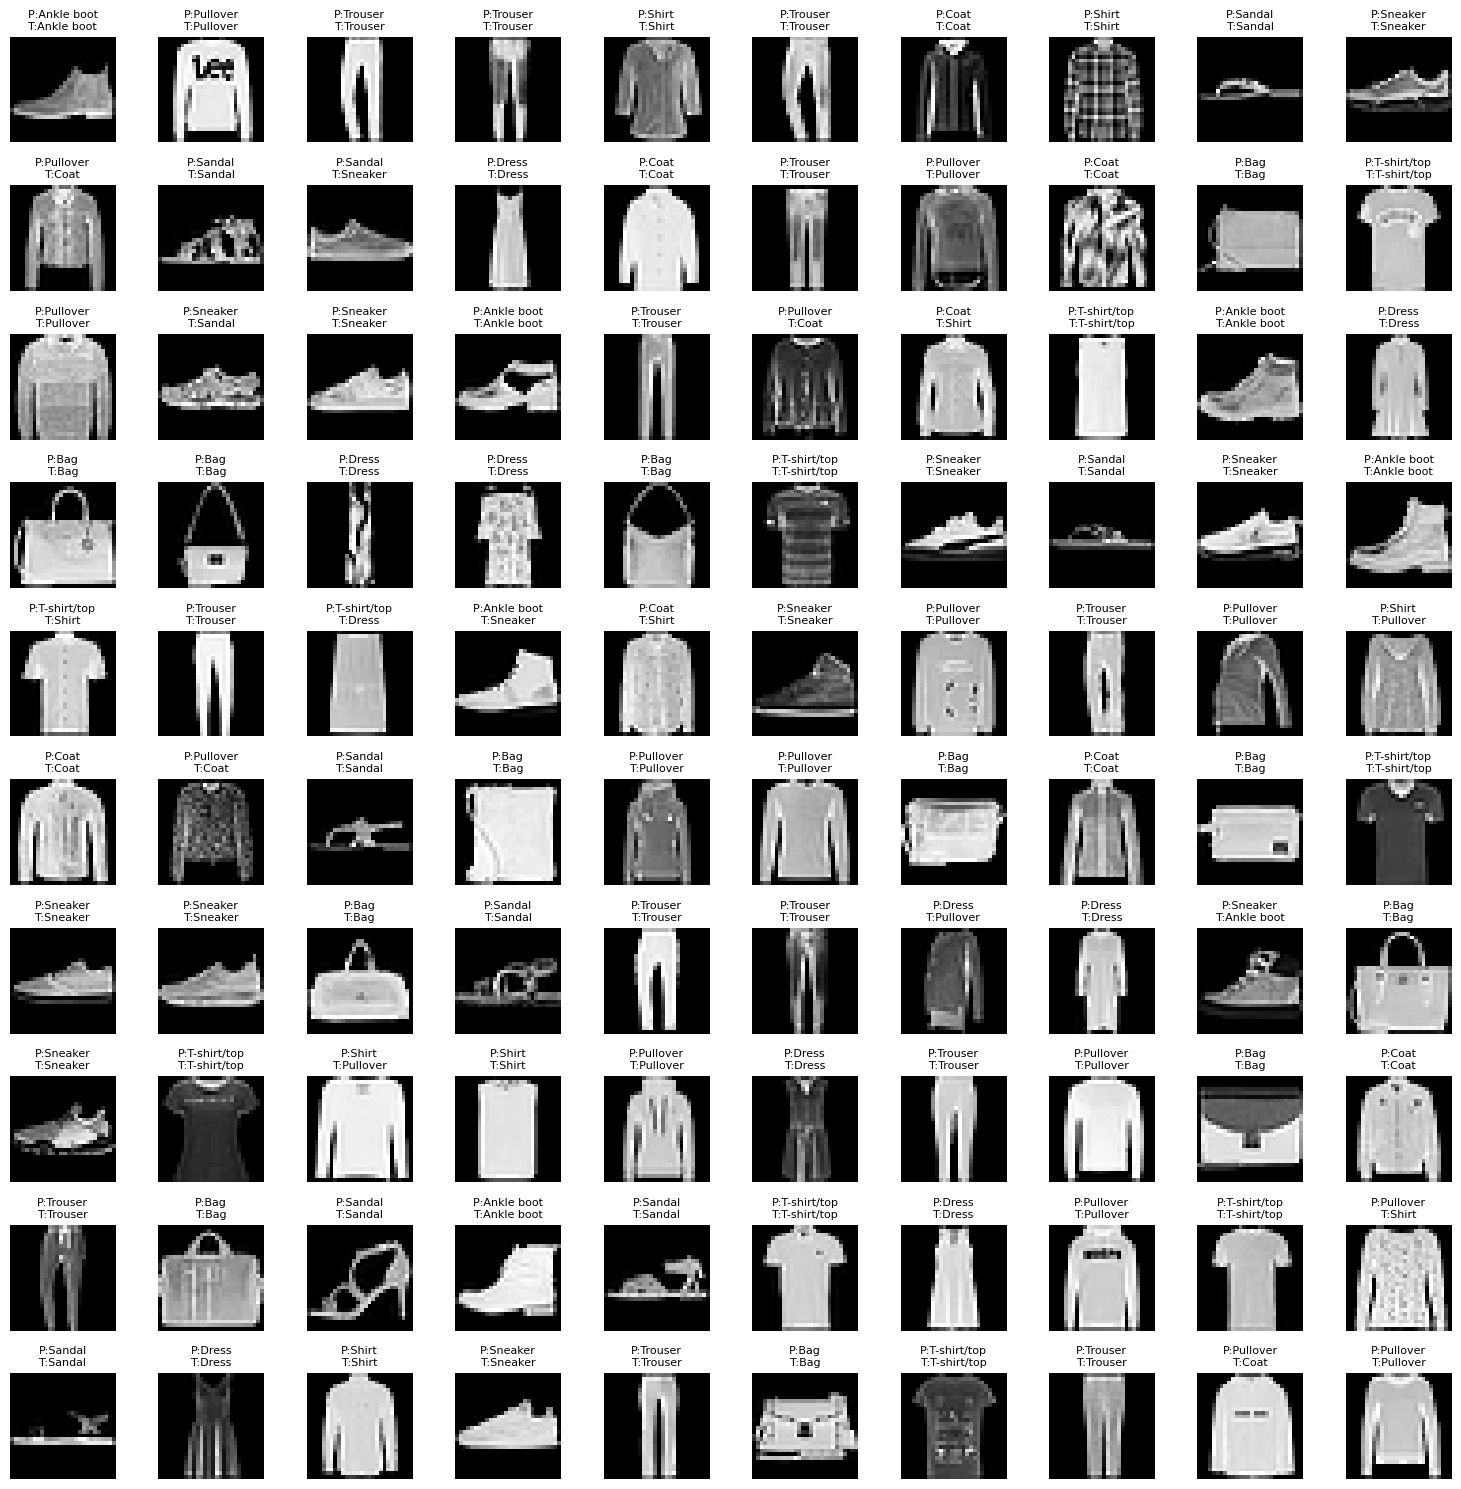


统计各类别准确率...

类别准确率统计:
T-shirt/top    : 81.20%
Trouser        : 93.10%
Pullover       : 79.90%
Dress          : 88.90%
Coat           : 65.90%
Sandal         : 94.90%
Shirt          : 47.80%
Sneaker        : 86.80%
Bag            : 96.30%
Ankle boot     : 96.70%


In [23]:
# 添加FashionMNIST类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#可视化100张测试图片和预测结果
def visualize_results():
    net.eval()
    # 获取100张测试图片（直接从testloader取一个batch）
    dataiter = iter(testloader)
    images, labels = next(dataiter)
    images = torch.squeeze(images, 1).to('cpu')  # 移除通道维度 [100, 28, 28]
    
    # 预测
    with torch.no_grad():
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
    
    # 绘制10x10网格（每行10张，共10行）
    plt.figure(figsize=(15, 15))
    for i in range(100):
        plt.subplot(10, 10, i+1)
        plt.imshow(images[i].numpy(), cmap='gray')
        plt.title(f'P:{class_names[predicted[i]]}\nT:{class_names[labels[i]]}', fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

#统计每个类别的准确率
def class_wise_accuracy():
    net.eval()
    class_correct = [0] * 10
    class_total = [0] * 10
    
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs = torch.squeeze(inputs, 1).to('cpu')
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            
            # 统计每个类别的正确预测数
            for i in range(10):
                mask = (targets == i)
                class_correct[i] += (predicted[mask] == targets[mask]).sum().item()
                class_total[i] += mask.sum().item()
    
    # 打印结果
    print("\n类别准确率统计:")
    for i in range(10):
        if class_total[i] > 0:
            print(f"{class_names[i]:<15}: {100 * class_correct[i] / class_total[i]:.2f}%")
        else:
            print(f"{class_names[i]:<15}: 无样本")

print("\n训练完成，开始可视化结果...")
visualize_results()
print("\n统计各类别准确率...")
class_wise_accuracy()